<a href="https://colab.research.google.com/github/GusthavoSoares/tech_challenge_data_analytics/blob/main/Analise_Receita_Olist_TechChallenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [95]:
#Importando bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [96]:
#Importando dataset
customers = pd.read_csv('olist_customers_dataset.csv')
orders = pd.read_csv('olist_orders_dataset.csv')
order_items = pd.read_csv('olist_order_items_dataset.csv')
payments = pd.read_csv('olist_order_payments_dataset.csv')
order_reviews = pd.read_csv('olist_order_reviews_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')
sellers = pd.read_csv('olist_sellers_dataset.csv')
geolocation = pd.read_csv('olist_geolocation_dataset.csv')

#Pergunta de Negócio: Qual categoria de produto teve maior valor de receita acumulado no período? Das top 5 categorias, qual teve maior taxa de crescimento médio mensal?

#Preparando o dataframe para análise  
Para a resposta da pergunta e uma análise mais aprofundada, utilizaremos algumas colunas de cada tabela para gerar um dataframe novo em cima do qual a análise será feita.

In [97]:
#Verificação das tabelas disponíveis no dataset
customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [98]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


De 'customers', serão utilizadas as colunas 'costumer_id', 'customer_city' e 'customer_state'

In [99]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [100]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


De 'orders' serão utilizadas as colunas 'order_id, 'customer_id', 'order_status' e 'order_approved_at'. Na análise serão consideradas apenas pedidos com o status 'entregue' e a data de compra como referência será a que o pedido foi aprovado.

In [101]:
order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [102]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


De 'order_items' serão utilizadas as colunas 'order_id', 'product_id', 'price' e 'freight_value'. A receita bruta será considerada igual a soma do preço do produto e frete do pedido.

In [103]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [104]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


De 'products' serão utilizadas as colunas 'product_id' e 'procut_category_name'. Dessa forma iremos definir qual a categoria com maior receita e crescimento no período

In [105]:
#Criação das tabelas principais para análise, considerando colunas selecionadas anteriormente e filtros

#Merge orders e customers utilizando 'customer_id'
df_analise = pd.merge(
    orders[['order_id', 'customer_id', 'order_status', 'order_approved_at', 'order_delivered_customer_date']],
    customers[['customer_id', 'customer_city', 'customer_state']],
    on='customer_id',
    how='inner'
)

#Merge df_analise e order_items utilizando 'order_id'
df_analise = pd.merge(
    df_analise,
    order_items[['order_id', 'product_id', 'price', 'freight_value']],
    on='order_id',
    how='inner'
)

#Merge df_analise e products utilizando 'product_id'
df_analise = pd.merge(
    df_analise,
    products[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#Aplicando o filtro apenas para analisarmos pedidos entregues
df_analise = df_analise[df_analise['order_status'] == 'delivered']

#Conversão de colunas de data para datetime
df_analise['order_approved_at'] = pd.to_datetime(df_analise['order_approved_at'])
df_analise['order_delivered_customer_date'] = pd.to_datetime(df_analise['order_delivered_customer_date'])

#Definindo as colunas princpiais para tratamento de valores nulos
colunas_principais = ['customer_id', 'customer_city', 'customer_state', 'order_id', 'order_approved_at', 'order_delivered_customer_date', 'product_id', 'product_category_name', 'price', 'freight_value']
df_analise.dropna(subset = colunas_principais, inplace = True)
df_analise.reset_index(drop = True, inplace = True)

#Definição final de df_analise
df_analise = df_analise[colunas_principais]

#Definição de df_produtos com as colunas necessárias
df_produtos = df_analise[['customer_id', 'customer_city', 'customer_state', 'order_id', 'product_id', 'product_category_name', 'price', 'freight_value', 'order_approved_at', 'order_delivered_customer_date']].copy()

# Calcular a quantidade de itens por pedido para realizar o rateio do frete
item_counts = df_produtos.groupby('order_id').size().reset_index(name='num_items_in_order')
df_produtos = pd.merge(df_produtos, item_counts, on='order_id', how='left')

# Calcular o frete rateado por item
df_produtos['freight_value_prorated'] = df_produtos['freight_value'] / df_produtos['num_items_in_order']

# Definir 'receita_bruta' como a soma do preço e do frete rateado
df_produtos['receita_bruta'] = df_produtos['price'] + df_produtos['freight_value_prorated']


In [106]:
#Verificação de df_analise
df_analise.head()

,customer_id,customer_city,customer_state,order_id,order_approved_at,order_delivered_customer_date,product_id,product_category_name,price,freight_value
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 11:07:15,2017-10-10 21:25:13,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,2018-07-26 03:24:27,2018-08-07 15:27:45,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:55:23,2018-08-17 18:06:29,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:45:59,2017-12-02 00:28:42,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 22:20:29,2018-02-16 18:17:02,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72


In [107]:
df_analise.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
order_id,0
order_approved_at,0
order_delivered_customer_date,0
product_id,0
product_category_name,0
price,0
freight_value,0


In [108]:
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108638 entries, 0 to 108637
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    108638 non-null  object        
 1   customer_city                  108638 non-null  object        
 2   customer_state                 108638 non-null  object        
 3   order_id                       108638 non-null  object        
 4   order_approved_at              108638 non-null  datetime64[ns]
 5   order_delivered_customer_date  108638 non-null  datetime64[ns]
 6   product_id                     108638 non-null  object        
 7   product_category_name          108638 non-null  object        
 8   price                          108638 non-null  float64       
 9   freight_value                  108638 non-null  float64       
dtypes: datetime64[ns](2), float64(2), object(6)
memory usage: 8.3+ MB


In [109]:
#Verificação de df_produtos
df_produtos

,customer_id,customer_city,customer_state,order_id,product_id,product_category_name,price,freight_value,order_approved_at,order_delivered_customer_date,num_items_in_order,freight_value_prorated,receita_bruta
0,9ef432eb6251297304e76186b10a928d,sao paulo,SP,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,utilidades_domesticas,29.99,8.72,2017-10-02 11:07:15,2017-10-10 21:25:13,1,8.720,38.710
1,b0830fb4747a6c6d20dea0b8c802d7ef,barreiras,BA,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,perfumaria,118.70,22.76,2018-07-26 03:24:27,2018-08-07 15:27:45,1,22.760,141.460
2,41ce2a54c0b03bf3443c3d931a367089,vianopolis,GO,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,automotivo,159.90,19.22,2018-08-08 08:55:23,2018-08-17 18:06:29,1,19.220,179.120
3,f88197465ea7920adcdbec7375364d82,sao goncalo do amarante,RN,949d5b44dbf5de918fe9c16f97b45f8a,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop,45.00,27.20,2017-11-18 19:45:59,2017-12-02 00:28:42,1,27.200,72.200
4,8ab97904e6daea8866dbdbc4fb7aad2c,santo andre,SP,ad21c59c0840e6cb83a9ceb5573f8159,65266b2da20d04dbe00c5c2d3bb7859e,papelaria,19.90,8.72,2018-02-13 22:20:29,2018-02-16 18:17:02,1,8.720,28.620
...,...,...,...,...,...,...,...,...,...,...,...,...,...
108633,1fca14ff2861355f6e5f14306ff977a7,praia grande,SP,63943bddc261676b46f01ca7ac2f7bd8,f1d4ce8c6dd66c47bbaa8c6781c2a923,bebes,174.90,20.10,2018-02-06 13:10:37,2018-02-28 17:37:56,1,20.100,195.000
108634,1aa71eb042121263aafbe80c1b562c9c,nova vicosa,BA,83c1379a015df1e13d02aae0204711ab,b80910977a37536adeddd63663f916ad,eletrodomesticos_2,205.99,65.02,2017-08-27 15:04:16,2017-09-21 11:24:17,1,65.020,271.010
108635,b331b74b18dc79bcdf6532d51e1637c1,japuiba,RJ,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,179.99,40.59,2018-01-08 21:36:21,2018-01-25 23:32:54,2,20.295,200.285
108636,b331b74b18dc79bcdf6532d51e1637c1,japuiba,RJ,11c177c8e97725db2631073c19f07b62,d1c427060a0f73f6b889a5c7c61f2ac4,informatica_acessorios,179.99,40.59,2018-01-08 21:36:21,2018-01-25 23:32:54,2,20.295,200.285


In [110]:
df_produtos.isna().sum()

,0
customer_id,0
customer_city,0
customer_state,0
order_id,0
product_id,0
product_category_name,0
price,0
freight_value,0
order_approved_at,0
order_delivered_customer_date,0


In [111]:
df_produtos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108638 entries, 0 to 108637
Data columns (total 13 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   customer_id                    108638 non-null  object        
 1   customer_city                  108638 non-null  object        
 2   customer_state                 108638 non-null  object        
 3   order_id                       108638 non-null  object        
 4   product_id                     108638 non-null  object        
 5   product_category_name          108638 non-null  object        
 6   price                          108638 non-null  float64       
 7   freight_value                  108638 non-null  float64       
 8   order_approved_at              108638 non-null  datetime64[ns]
 9   order_delivered_customer_date  108638 non-null  datetime64[ns]
 10  num_items_in_order             108638 non-null  int64         
 11  

#Início da Análise, definição das 5 categorias com maior receita no período

In [112]:
#Definição das 5 categorias com maior receita
top5_categorias = df_produtos.groupby('product_category_name')['receita_bruta'].sum().sort_values(ascending=False).head(5).index.tolist()
top5_categorias

['beleza_saude',
 'relogios_presentes',
 'cama_mesa_banho',
 'esporte_lazer',
 'informatica_acessorios']

In [113]:
#Criação de tabela com as top 5 categorias e agrupando as receita das categorias por mês
df_top5_produtos = df_produtos[df_produtos['product_category_name'].isin(top5_categorias)].copy()
df_top5_produtos['mes'] = df_top5_produtos['order_approved_at'].dt.to_period('M').dt.start_time
receita_mensal_por_categoria = df_top5_produtos.groupby(['product_category_name', 'mes'])['receita_bruta'].sum().reset_index()
receita_mensal_por_categoria.head()

,product_category_name,mes,receita_bruta
0,beleza_saude,2016-09-01,137.800000
1,beleza_saude,2016-10-01,4110.160000
2,beleza_saude,2017-01-01,11852.780000
3,beleza_saude,2017-02-01,26790.226667
4,beleza_saude,2017-03-01,29226.810000


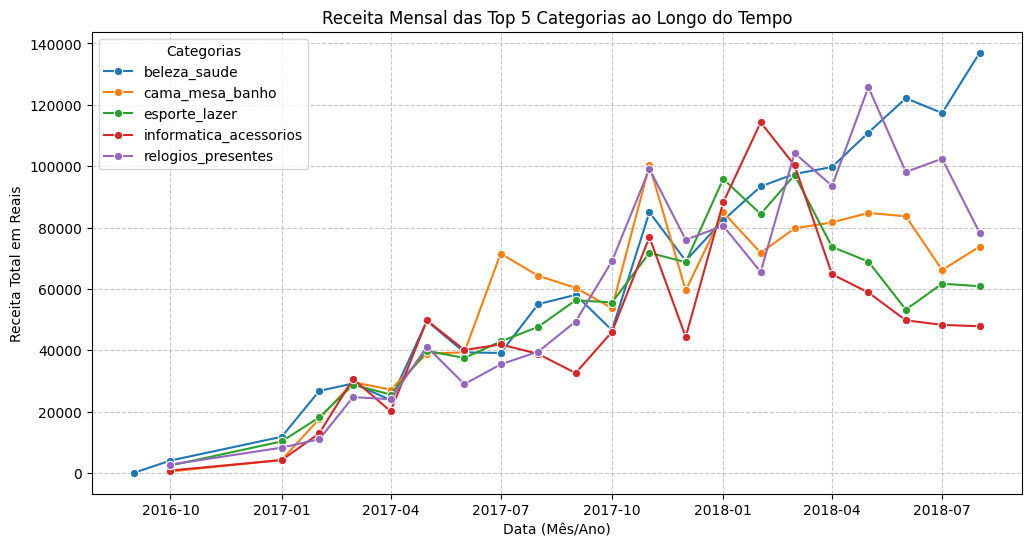

In [114]:
#Visualização da Receita Mensal das Top 5 Categorias ao longo do tempo
plt.figure(figsize=(12,6))
sns.lineplot(data=receita_mensal_por_categoria, x='mes', y='receita_bruta', hue='product_category_name', marker='o')
plt.title('Receita Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

Como apenas a categoria 'beleza_saude' tem dados de antes de outbro de 2016 e não temos dados dos meses de novembro e dezembro de 2016, adotaremos um novo filtro considerando a partir de janeiro de 2017

In [115]:
#Filtrando os dados a partir de janeiro de 2017 para garantir dados consistentes para todas as categorias
receita_mensal_por_categoria_filtrada = receita_mensal_por_categoria[receita_mensal_por_categoria['mes'] >= '2017-01-01'].copy()


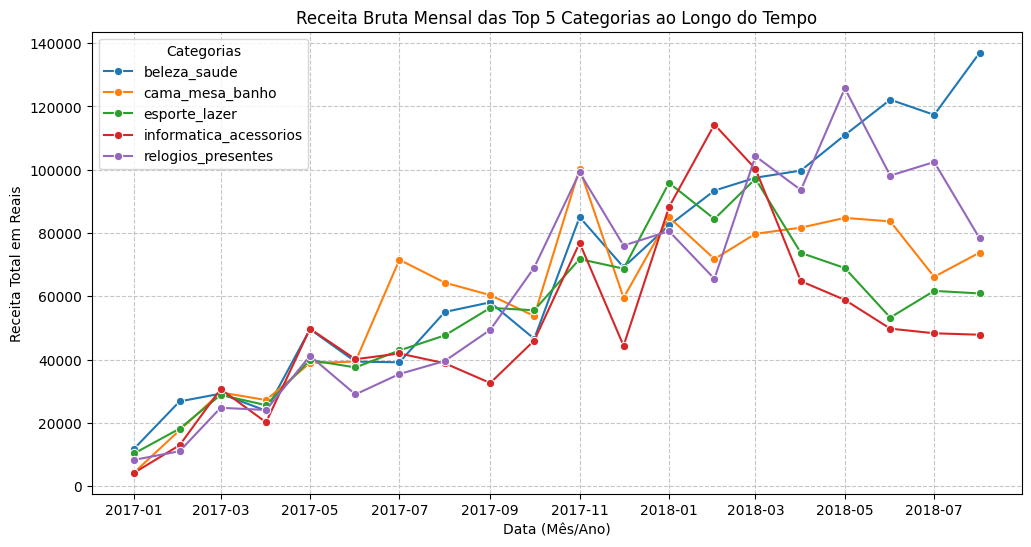

In [146]:
#Visualização da Receita Mensal das Top 5 Categorias ao longo do tempo (Jan/17 - Ago/18)
plt.figure(figsize=(12,6))
sns.lineplot(data=receita_mensal_por_categoria_filtrada, x='mes', y='receita_bruta', hue='product_category_name', marker='o')
plt.title('Receita Bruta Mensal das Top 5 Categorias ao Longo do Tempo')
plt.xlabel('Data (Mês/Ano)')
plt.ylabel('Receita Total em Reais')
plt.xticks(rotation=0)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.legend(title='Categorias')
plt.show()

No gráfico acima é possível ver o corportamento mês a mês das receitas das categorias, a partir da análise abaixo, validaremos qual categoria teve maior crescimento de receita dentro do período (Jan/17 - Ago/18)

In [117]:
#Cálculo da receita para o primeiro e o último mês de cada categoria
receita_por_categoria = receita_mensal_por_categoria_filtrada.groupby('product_category_name').agg(
    receita_primeiro_mes  = ('receita_bruta', 'first'),
    receita_ultimo_mes = ('receita_bruta', 'last')
).reset_index()

# Calcular o número de meses no período filtrado
num_meses = receita_mensal_por_categoria_filtrada['mes'].nunique()

#Função para calcular a porcentagem de crescimento
def percentual_crescimento_receita_mensal(linha):
    if linha['receita_primeiro_mes'] > 0:
        n = num_meses
        return ((linha['receita_ultimo_mes'] / linha['receita_primeiro_mes']) ** (1/n) - 1) * 100
    else:
        return 0

#Aplicando a função para calcular a porcentagem de crescimento
receita_por_categoria['percentual_de_crescimento'] = receita_por_categoria.apply(percentual_crescimento_receita_mensal, axis=1)

receita_por_categoria.sort_values(by='percentual_de_crescimento', ascending = False).round(2)

,product_category_name,receita_primeiro_mes,receita_ultimo_mes,percentual_de_crescimento
1,cama_mesa_banho,4323.14,73818.50,15.24
0,beleza_saude,11852.78,136985.68,13.02
3,informatica_acessorios,4249.68,47859.85,12.87
4,relogios_presentes,8310.83,78308.11,11.87
2,esporte_lazer,10352.15,60902.70,9.26


Com a tabela acima, temos que a categoria que teve a maior taxa de crescimento médio mensal no período foi 'cama_mesa_banho' seguida por 'beleza_saude' e 'informatica_acessorios'. Mesmo com 'beleza_saude' tendo a maior receita acumulada no período, conforme visto na tabela abaixo:

In [118]:
#Verificação da receita total por categoria
receita_mensal_por_categoria_filtrada.groupby('product_category_name')['receita_bruta'].sum().sort_values(ascending=False).reset_index()

,product_category_name,receita_bruta
0,beleza_saude,1.394291e+06
1,relogios_presentes,1.255685e+06
2,cama_mesa_banho,1.193806e+06
3,esporte_lazer,1.099360e+06
4,informatica_acessorios,1.010977e+06


In [119]:
receita_total_por_categoria = receita_mensal_por_categoria_filtrada.groupby('product_category_name')['receita_bruta'].sum().reset_index()
receita_total_por_categoria.rename(columns={'receita_bruta': 'receita_total_acumulada'}, inplace=True)

tabela_crescimento_e_receita = pd.merge(
    receita_por_categoria,
    receita_total_por_categoria,
    on='product_category_name',
    how='inner'
)

tabela_crescimento_e_receita.sort_values(by='percentual_de_crescimento', ascending=False).round(2)

,product_category_name,receita_primeiro_mes,receita_ultimo_mes,percentual_de_crescimento,receita_total_acumulada
1,cama_mesa_banho,4323.14,73818.50,15.24,1193806.15
0,beleza_saude,11852.78,136985.68,13.02,1394290.67
3,informatica_acessorios,4249.68,47859.85,12.87,1010976.73
4,relogios_presentes,8310.83,78308.11,11.87,1255684.67
2,esporte_lazer,10352.15,60902.70,9.26,1099360.42


A partir da identificação das categorias com maior receita acumulada e maior taxa de crescimento médio mensal, é possível aprofundar a análise avaliando como essas categorias se comportam regionalmente. Essa abordagem permite entender se o desempenho observado no cenário geral se mantém de forma consistente entre as regiões ou se existem variações que indiquem oportunidades específicas de atuação, contribuindo para uma visão mais estratégica da distribuição e potencial de crescimento das categorias.

# Análise do Desempenho das 5 categorias com maior receita nas regiões do país



In [120]:
mapa_regiao = {
    'SP': 'Sudeste', 'RJ': 'Sudeste', 'MG': 'Sudeste', 'ES': 'Sudeste',
    'RS': 'Sul', 'SC': 'Sul', 'PR': 'Sul',
    'BA': 'Nordeste', 'PE': 'Nordeste', 'CE': 'Nordeste', 'AL': 'Nordeste', 'MA': 'Nordeste', 'PB': 'Nordeste', 'PI': 'Nordeste', 'RN': 'Nordeste', 'SE': 'Nordeste',
    'AM': 'Norte', 'PA': 'Norte', 'AC': 'Norte', 'AP': 'Norte', 'RO': 'Norte', 'RR': 'Norte', 'TO': 'Norte',
    'DF': 'Centro-Oeste', 'GO': 'Centro-Oeste', 'MT': 'Centro-Oeste', 'MS': 'Centro-Oeste'
}

In [121]:
#Criação de ranking de receita por categoria, para avaliar a posição das top 5 categorias nacionais dentro de cada região do páis
df_produtos['regiao'] = df_produtos['customer_state'].map(mapa_regiao)
df_top5_produtos['regiao'] = df_top5_produtos['customer_state'].map(mapa_regiao)
receita_todas_categorias_regional = df_produtos.groupby(['regiao', 'product_category_name'])['receita_bruta'].sum().reset_index()
receita_todas_categorias_regional['rank_regional'] = receita_todas_categorias_regional.groupby('regiao')['receita_bruta'].rank(ascending=False).astype(int)
tabela_pivot_rank_todas_categorias = receita_todas_categorias_regional.pivot_table(index='product_category_name', columns='regiao', values='rank_regional', fill_value=999)

In [122]:
# Filtrar a tabela_pivot_rank_todas_categorias para incluir apenas as top 5 categorias globais
tabela_pivot_rank_top5_globais = tabela_pivot_rank_todas_categorias[tabela_pivot_rank_todas_categorias.index.isin(top5_categorias)].copy()

if 'Sudeste' in tabela_pivot_rank_top5_globais.columns:
    tabela_pivot_rank_top5_globais = tabela_pivot_rank_top5_globais.sort_values(by='Sudeste')
else:
    tabela_pivot_rank_top5_globais = tabela_pivot_rank_top5_globais.sort_values(by=tabela_pivot_rank_top5_globais.columns[0])

tabela_pivot_rank_top5_globais

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul
product_category_name,,,,,
cama_mesa_banho,5.0,9.0,13.0,1.0,3.0
beleza_saude,1.0,1.0,1.0,2.0,2.0
relogios_presentes,2.0,2.0,2.0,3.0,6.0
esporte_lazer,3.0,3.0,3.0,4.0,1.0
informatica_acessorios,4.0,4.0,4.0,5.0,5.0


A análise regional evidencia um comportamento parcialmente homogêneo entre as principais categorias, com destaque para 'beleza_saude', 'esporte_lazer' e 'informatica_acessorios', que mantêm posicionamentos semelhantes em todas as regiões, indicando uma demanda mais consolidada e consistente em nível nacional.

Por outro lado, a categoria 'relogios_presentes' apresenta uma leve perda de relevância na região Sul, quando comparada às demais regiões, sugerindo uma possível diferença no perfil de consumo local ou na competitividade da categoria.

Já a categoria 'cama_mesa_banho' demonstra maior variação regional, com forte desempenho no Sudeste e Sul, mas baixa representatividade no Norte e Nordeste, evidenciando um potencial de expansão nessas regiões.

Esse cenário indica que, enquanto algumas categorias apresentam demanda consolidada em todo o país, outras possuem oportunidades de crescimento condicionadas a estratégias específicas por região, reforçando a importância de abordagens segmentadas para maximizar o desempenho.

#Validação da hipotese de oportunidades para cama_mesa_banho nas regiões de Norte e Nordeste e causa da baixa de desempenho de relogios_presentes no sul

Para validar a hipótese de oportunidade na categoria ‘Cama, Mesa e Banho’, será realizada a análise dos indicadores de ticket médio e avaliação dos pedidos, com o objetivo de avaliar seu potencial de geração de receita e o nível de aceitação por parte dos consumidores.

In [145]:
# Calcular o ticket médio geral (receita por item) para TODAS as categorias
ticket_medio_geral_todas_categorias = df_produtos.groupby('product_category_name')['receita_bruta'].mean().reset_index()
ticket_medio_geral_todas_categorias.rename(columns={'receita_bruta': 'ticket_medio_geral'}, inplace=True)

# Calcular a posição no ranking geral de ticket médio para todas as categorias
ticket_medio_geral_todas_categorias['posicao_ranking_geral_ticket_medio'] = ticket_medio_geral_todas_categorias['ticket_medio_geral'].rank(ascending=False).astype(int)

# Ordenar a tabela pelo ranking
tabela_ticket_medio_ranking_todas_categorias = ticket_medio_geral_todas_categorias.sort_values(by='posicao_ranking_geral_ticket_medio').round(2)

# Filtrar a tabela de ranking de ticket médio geral para incluir apenas as top 5 categorias globais de receita
tabela_ticket_medio_top5_global_ranking = tabela_ticket_medio_ranking_todas_categorias[
    tabela_ticket_medio_ranking_todas_categorias['product_category_name'].isin(top5_categorias)
].sort_values(by='posicao_ranking_geral_ticket_medio').round(2)

tabela_ticket_medio_top5_global_ranking

,product_category_name,ticket_medio_geral,posicao_ranking_geral_ticket_medio
66,relogios_presentes,214.87,11
11,beleza_saude,147.76,33
44,informatica_acessorios,132.39,36
32,esporte_lazer,130.74,38
13,cama_mesa_banho,109.05,46


In [129]:
# Merge df_produtos com order_reviews para incluir as avaliações
df_produtos_com_avaliacoes = pd.merge(
    df_produtos,
    order_reviews[['order_id', 'review_score']],
    on='order_id',
    how='left'  # Usar left merge para manter todos os produtos, mesmo que não tenham avaliação
)

# Tratar valores nulos que possam surgir do merge (se alguma avaliação não for encontrada)
df_produtos_com_avaliacoes.dropna(subset=['review_score'], inplace=True)


# Calcular a avaliação média geral para TODAS as categorias
avaliacao_media_geral_todas_categorias = df_produtos_com_avaliacoes.groupby('product_category_name')['review_score'].mean().reset_index()
avaliacao_media_geral_todas_categorias.rename(columns={'review_score': 'avaliacao_media_geral'}, inplace=True)

# Calcular a posição no ranking geral de avaliação média para todas as categorias
avaliacao_media_geral_todas_categorias['posicao_ranking_geral_avaliacao_media'] = avaliacao_media_geral_todas_categorias['avaliacao_media_geral'].rank(ascending=False).astype(int)

# Ordenar a tabela pelo ranking para melhor visualização
tabela_avaliacao_media_ranking_todas_categorias = avaliacao_media_geral_todas_categorias.sort_values(by='posicao_ranking_geral_avaliacao_media').round(2)

# Filtrar a tabela de ranking de avaliação média geral para incluir apenas as top 5 categorias globais de receita
tabela_avaliacao_media_top5_global_ranking = tabela_avaliacao_media_ranking_todas_categorias[
    tabela_avaliacao_media_ranking_todas_categorias['product_category_name'].isin(top5_categorias)
].sort_values(by='posicao_ranking_geral_avaliacao_media').round(2)

tabela_avaliacao_media_top5_global_ranking

,product_category_name,avaliacao_media_geral,posicao_ranking_geral_avaliacao_media
11,beleza_saude,4.19,27
32,esporte_lazer,4.17,29
66,relogios_presentes,4.07,47
44,informatica_acessorios,3.99,55
13,cama_mesa_banho,3.92,61


A categoria ‘Cama, Mesa e Banho’ apresenta baixo ticket médio e menor avaliação em comparação às demais categorias analisadas, o que ajuda a explicar seu baixo desempenho relativo em determinadas regiões.

Nesse contexto, o desafio não está apenas na expansão regional, mas na competitividade da categoria, indicando a necessidade de melhorias na proposta de valor — como qualidade dos produtos, percepção do cliente ou estratégia de precificação — antes de direcionar investimentos para crescimento.

A análise deve ser complementada pela avaliação do volume de pedidos. Caso seja identificado alto volume, isso indica a existência de demanda relevante, ainda que acompanhada de menor ticket médio e avaliações inferiores.

In [130]:
# Calcular a quantidade de pedidos para as top 5 categorias, dividindo por região
quantidade_pedidos_top5_regional = df_top5_produtos.groupby(['regiao', 'product_category_name'])['order_id'].nunique().reset_index()
quantidade_pedidos_top5_regional.rename(columns={'order_id': 'quantidade_pedidos'}, inplace=True)

# Criar a matriz com regiões nas colunas, categorias nas linhas e quantidade de pedidos como valores
matriz_pedidos_por_regiao_categoria = quantidade_pedidos_top5_regional.pivot_table(
    index='product_category_name',
    columns='regiao',
    values='quantidade_pedidos',
    fill_value=0 # Preencher valores ausentes com 0
)

# Adicionar uma coluna totalizadora
matriz_pedidos_por_regiao_categoria['Total'] = matriz_pedidos_por_regiao_categoria.sum(axis=1)

matriz_pedidos_por_regiao_categoria

regiao,Centro-Oeste,Nordeste,Norte,Sudeste,Sul,Total
product_category_name,,,,,,
beleza_saude,565.0,1054.0,187.0,5795.0,1046.0,8647.0
cama_mesa_banho,472.0,503.0,73.0,7021.0,1202.0,9271.0
esporte_lazer,462.0,660.0,144.0,5119.0,1142.0,7527.0
informatica_acessorios,342.0,618.0,141.0,4449.0,979.0,6529.0
relogios_presentes,367.0,721.0,132.0,3620.0,653.0,5493.0


In [139]:
# Extrair a linha da categoria 'cama_mesa_banho' do DataFrame de pedidos por região e categoria
pedidos_cama_mesa_banho = matriz_pedidos_por_regiao_categoria.loc[['cama_mesa_banho']].transpose()
pedidos_cama_mesa_banho.columns = ['quantidade_pedidos']
pedidos_cama_mesa_banho.index.name = 'regiao'

# Remover a linha 'Total' que pode ter vindo no transpose
pedidos_cama_mesa_banho = pedidos_cama_mesa_banho.drop('Total', errors='ignore')

# Calcular o total de pedidos para 'cama_mesa_banho' em todas as regiões
total_pedidos_cama_mesa_banho_geral = pedidos_cama_mesa_banho['quantidade_pedidos'].sum()

# Calcular a porcentagem do total para cada região
pedidos_cama_mesa_banho['porcentagem_do_total'] = (pedidos_cama_mesa_banho['quantidade_pedidos'] / total_pedidos_cama_mesa_banho_geral * 100).round(2)

# Adicionar a linha de totalização
total_row = pd.DataFrame({
    'quantidade_pedidos': [total_pedidos_cama_mesa_banho_geral],
    'porcentagem_do_total': [100.00]
}, index=['Total'])

tabela_cama_mesa_banho_regional = pd.concat([pedidos_cama_mesa_banho, total_row])

tabela_cama_mesa_banho_regional.sort_values(by='porcentagem_do_total', ascending=False)

,quantidade_pedidos,porcentagem_do_total
Total,9271.0,100.00
Sudeste,7021.0,75.73
Sul,1202.0,12.97
Nordeste,503.0,5.43
Centro-Oeste,472.0,5.09
Norte,73.0,0.79


/tmp/ipykernel_847/594301108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_plot.index, y='quantidade_pedidos', data=df_plot, palette='viridis')


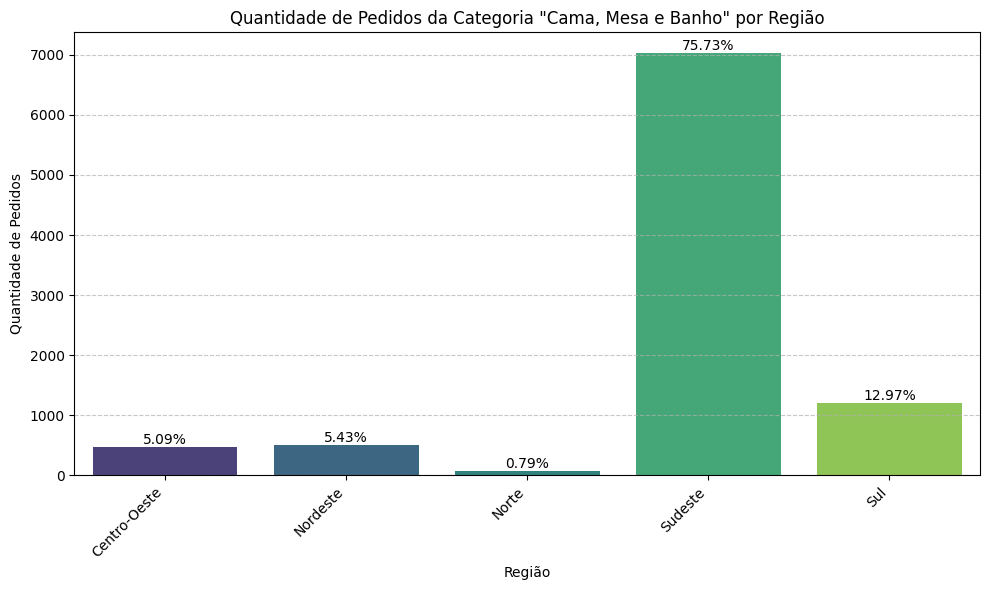

In [147]:
# Filtrar a tabela para remover a linha 'Total' antes de plotar
df_plot = tabela_cama_mesa_banho_regional[tabela_cama_mesa_banho_regional.index != 'Total'].copy()

plt.figure(figsize=(10, 6))
sns.barplot(x=df_plot.index, y='quantidade_pedidos', data=df_plot, palette='viridis')
plt.title('Quantidade de Pedidos da Categoria "Cama, Mesa e Banho" por Região')
plt.xlabel('Região')
plt.ylabel('Quantidade de Pedidos')
plt.xticks(rotation=45, ha='right')

# Adicionar rótulos de porcentagem nas barras
for index, row in df_plot.iterrows():
    plt.text(index, row['quantidade_pedidos'], f'{row["porcentagem_do_total"]:.2f}%',
             color='black', ha="center", va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

A categoria ‘Cama, Mesa e Banho’ apresenta forte concentração no Sudeste, responsável por cerca de 76% das vendas, indicando dependência regional e baixa penetração nas demais regiões.

Considerando seu baixo ticket médio e avaliações inferiores, o principal desafio está na competitividade da categoria. Para expandir, recomenda-se melhorar a qualidade percebida e experiência do cliente, elevando avaliações, e investir em campanhas direcionadas nas regiões Norte e Nordeste, utilizando prova social (reviews) e incentivos à experimentação.

Dessa forma, é possível reduzir a dependência regional e impulsionar o crescimento da categoria de forma mais equilibrada.

Para analisar a menor performance da categoria ‘Relógios e Presentes’ na região Sul, será realizada uma avaliação do ticket médio das principais categorias da região, com o objetivo de entender como o valor por transação influencia o posicionamento e a competitividade da categoria no contexto regional.

In [144]:
# Filtrar os dados da região Sul
df_sul = df_produtos[df_produtos['regiao'] == 'Sul'].copy()

# Calcular a receita acumulada total e o ticket médio por categoria para a região Sul
receita_ticket_medio_sul = df_sul.groupby('product_category_name').agg(
    receita_acumulada_total=('receita_bruta', 'sum'),
    ticket_medio_por_categoria=('receita_bruta', 'mean')
).reset_index()

# Ordenar pela receita acumulada total e pegar as top 10
top_10_receitas_sul = receita_ticket_medio_sul.sort_values(
    by='receita_acumulada_total', ascending=False
).head(10).round(2)

# Renomear colunas para o output desejado
top_10_receitas_sul.rename(columns={'product_category_name': 'Categorias'}, inplace=True)

top_10_receitas_sul

,Categorias,receita_acumulada_total,ticket_medio_por_categoria
32,esporte_lazer,173337.64,133.44
11,beleza_saude,164343.40,143.53
13,cama_mesa_banho,160489.49,114.72
54,moveis_decoracao,159707.31,112.63
44,informatica_acessorios,150813.12,128.57
66,relogios_presentes,149390.62,209.52
26,cool_stuff,123034.95,194.68
71,utilidades_domesticas,115635.93,113.15
8,automotivo,92330.26,156.49
40,ferramentas_jardim,90777.20,135.29


In [143]:
top_10_receitas_sul.ticket_medio_por_categoria.median()

134.365

A análise do ticket médio das principais categorias na região Sul, considerando a mediana de aproximadamente 134 reais, evidencia que ‘Relógios e Presentes’ apresenta valor significativamente superior, com ticket médio de 209 reais, posicionando-se como uma categoria premium dentro do contexto regional.

Esse nível de preço pode representar uma barreira à conversão, especialmente em um cenário onde o consumo tende a se concentrar em faixas de menor valor. No entanto, mesmo com esse posicionamento acima da mediana, a categoria não apresenta desempenho proporcional em receita, indicando que o ticket elevado, embora relevante, não explica isoladamente seu desempenho.

Dessa forma, o fator limitante pode estar associado também ao volume de vendas, à penetração da categoria e à sua visibilidade no mercado regional, reforçando a existência de uma oportunidade de crescimento por meio de estratégias voltadas ao aumento de demanda e ampliação de presença.

#Conclusão

A análise das categorias mostra que o desempenho de receita é resultado da combinação entre volume, crescimento, ticket médio e distribuição regional. Categorias como *Beleza e Saúde* apresentam alta receita e presença consistente em todas as regiões, sendo fundamentais para sustentar o negócio e devendo ter foco em manutenção de performance e ganho de eficiência.

Por outro lado, *Cama, Mesa e Banho* apresenta alto crescimento e grande volume de pedidos, mas forte concentração no Sudeste e baixo desempenho no Norte e Nordeste. Além disso, possui ticket médio mais baixo e avaliações inferiores. Nesse caso, recomenda-se priorizar melhorias na qualidade percebida e experiência do cliente, revisar precificação e comunicação de valor, e somente após isso investir em expansão regional com campanhas direcionadas e incentivos à experimentação.

Já *Relógios e Presentes* possui ticket médio elevado, acima da mediana regional no Sul, mas não converte esse valor em receita proporcional. Isso sugere dificuldade de conversão. Recomenda-se aumentar a visibilidade da categoria, trabalhar ofertas promocionais ou condições facilitadas e adaptar a comunicação para reduzir a percepção de preço elevado, buscando aumentar volume de vendas.

De forma geral, as categorias apresentam comportamento semelhante entre regiões, mas com exceções relevantes que indicam oportunidades. A estratégia deve focar em manter o desempenho das categorias líderes e atuar de forma direcionada nas categorias com menor performance, ajustando proposta de valor, visibilidade e estratégia comercial conforme as características de cada região.
